In [1]:
'''from src.anomaly.lstm_autoencoder import LSTMAutoencoder

model = LSTMAutoencoder(
    n_features=3
)

print(model)'''

LSTMAutoencoder(
  (encoder): LSTM(3, 32, batch_first=True)
  (latent): Linear(in_features=32, out_features=16, bias=True)
  (expand): Linear(in_features=16, out_features=32, bias=True)
  (decoder): LSTM(32, 3, batch_first=True)
)


In [2]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

from src.anomaly.sequence_dataset import create_sequences
from src.anomaly.lstm_autoencoder import LSTMAutoencoder

In [3]:
import pykitti
from pathlib import Path

base = Path.home() / "SensorTrust" / "datasets" / "kitti"

data = pykitti.raw(
    base_path=str(base),
    date="2011_09_26",
    drive="0009"
)

print(len(data.oxts))

447


In [4]:
from src.proxies.lidar_proxy import extract_all_lidar_proxies
from src.proxies.camera_proxy import extract_all_camera_proxies
from src.proxies.imu_proxy import extract_all_imu_proxies
from src.proxies.gps_proxy import extract_all_gps_proxies

# clean proxies
gps_clean = extract_all_gps_proxies(data.oxts, dt=0.1035)

imu_clean = extract_all_imu_proxies(
    data.oxts,
    dt=0.1035
)

camera_frames = [np.array(f) for f in list(data.cam2)]

camera_clean = extract_all_camera_proxies(
    camera_frames
)

velo_scans = list(data.velo)

lidar_clean = extract_all_lidar_proxies(
    velo_scans,
    data.oxts[:len(velo_scans)]
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443


In [5]:
from src.features.gmis import compute_gmis
from src.features.f2_scene import compute_f2
from src.features.normalization import MotionNormalizer
from src.features.f1_kinematic import extract_all_f1_features

normalizer = MotionNormalizer()

normalizer.fit(
    gps_clean,
    imu_clean,
    camera_clean,
    lidar_clean
)

z_clean = normalizer.transform(
    gps_clean,
    imu_clean,
    camera_clean,
    lidar_clean
)


f1_clean = extract_all_f1_features(
    z=z_clean,
    gps_speed=gps_clean["speed"]
)["f1"]


min_len = min(
    len(z_clean["gps_delta_v"]),
    len(z_clean["lidar_icp"])
)

f2_clean = compute_f2(
    z_clean["gps_delta_v"][:min_len],
    z_clean["lidar_icp"][:min_len]
)

min_len = min(
    len(z_clean["gps_delta_v"]),
    len(z_clean["imu_delta_v"]),
    len(z_clean["lidar_icp"]),
    len(z_clean["camera_flow"])
)

gmis_clean = compute_gmis(
    z_clean["gps_delta_v"][:min_len],
    z_clean["imu_delta_v"][:min_len],
    z_clean["lidar_icp"][:min_len],
    z_clean["camera_flow"][:min_len]
)

Normalization parameters fitted:
  gps_delta_v         : μ= -0.1212, σ=  0.4548
  gps_heading_rate    : μ=  0.0423, σ=  1.7530
  imu_delta_v         : μ= -0.1656, σ=  0.4658
  imu_yaw_rate        : μ=  0.0279, σ=  0.1016
  camera_flow         : μ= 11.7695, σ=  5.5256
  lidar_icp           : μ=  0.1131, σ=  0.0318


In [8]:
min_len = min(
    len(f1_clean),
    len(f2_clean),
    len(gmis_clean)
)

X_clean = np.column_stack([
    f1_clean[:min_len],
    f2_clean[:min_len],
    gmis_clean[:min_len]
])

print(X_clean.shape)

(442, 3)


In [7]:
print(len(f1_clean))
print(len(f2_clean))
print(len(gmis_clean))

447
442
442


In [9]:
X_clean = X_clean[
    ~np.isnan(X_clean).any(axis=1)
]

print(X_clean.shape)

(437, 3)


In [31]:
SEQ_LEN = 200

X_seq = create_sequences(
    X_clean,
    seq_len=SEQ_LEN
)

print(X_seq.shape)

(238, 200, 3)


In [33]:
X_tensor = torch.tensor(
    X_seq,
    dtype=torch.float32
)

dataset = TensorDataset(
    X_tensor,
    X_tensor
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print(len(loader))

8


In [34]:
'''create model'''
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = LSTMAutoencoder(
    n_features=3,
    hidden_size=64,
    latent_size=32
).to(device)

print(device)
print(model)

cpu
LSTMAutoencoder(
  (encoder): LSTM(3, 64, batch_first=True)
  (latent): Linear(in_features=64, out_features=32, bias=True)
  (expand): Linear(in_features=32, out_features=64, bias=True)
  (decoder): LSTM(64, 3, batch_first=True)
)


In [35]:
'''loss + optimizer'''
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-4
)

In [36]:
'''training loop'''
EPOCHS = 150

losses = []

for epoch in range(EPOCHS):

    model.train()

    epoch_loss = 0

    for batch_x, _ in loader:

        batch_x = batch_x.to(device)

        optimizer.zero_grad()

        reconstructed = model(batch_x)

        loss = criterion(
            reconstructed,
            batch_x
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(loader)

    losses.append(epoch_loss)

    print(
        f"Epoch {epoch+1:03d}/{EPOCHS} | "
        f"Loss = {epoch_loss:.6f}"
    )

Epoch 001/150 | Loss = 1.443325
Epoch 002/150 | Loss = 1.279068
Epoch 003/150 | Loss = 1.118765
Epoch 004/150 | Loss = 0.977679
Epoch 005/150 | Loss = 0.834057
Epoch 006/150 | Loss = 0.760567
Epoch 007/150 | Loss = 0.763851
Epoch 008/150 | Loss = 0.756089
Epoch 009/150 | Loss = 0.755064
Epoch 010/150 | Loss = 0.752437
Epoch 011/150 | Loss = 0.750430
Epoch 012/150 | Loss = 0.747782
Epoch 013/150 | Loss = 0.753341
Epoch 014/150 | Loss = 0.747865
Epoch 015/150 | Loss = 0.748228
Epoch 016/150 | Loss = 0.746878
Epoch 017/150 | Loss = 0.746522
Epoch 018/150 | Loss = 0.747723
Epoch 019/150 | Loss = 0.747267
Epoch 020/150 | Loss = 0.744459
Epoch 021/150 | Loss = 0.741970
Epoch 022/150 | Loss = 0.743823
Epoch 023/150 | Loss = 0.743354
Epoch 024/150 | Loss = 0.737284
Epoch 025/150 | Loss = 0.734618
Epoch 026/150 | Loss = 0.740155
Epoch 027/150 | Loss = 0.740627
Epoch 028/150 | Loss = 0.739335
Epoch 029/150 | Loss = 0.738073
Epoch 030/150 | Loss = 0.740422
Epoch 031/150 | Loss = 0.740018
Epoch 03

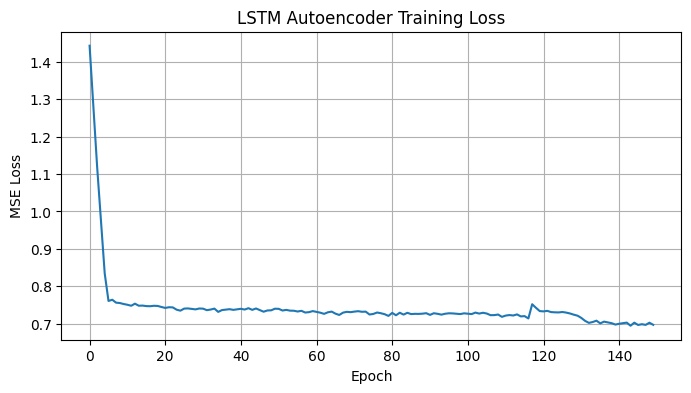

In [37]:
'''plot training loss'''
plt.figure(figsize=(8,4))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Autoencoder Training Loss")

plt.grid(True)
plt.show()

In [16]:
print(X_clean.shape)
print(X_seq.shape)

(437, 3)
(418, 20, 3)


In [38]:
from pathlib import Path

MODEL_PATH = Path("../src/models/lstm_autoencoder.pt")

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print("Saved to:", MODEL_PATH.resolve())

Saved to: C:\Users\disha\SensorTrust\src\models\lstm_autoencoder.pt


RECONSTRUCTION ERROR ON CLEAN DATA

In [39]:
model.eval()

errors = []

with torch.no_grad():

    for batch_x, _ in loader:

        batch_x = batch_x.to(device)

        reconstructed = model(batch_x)

        mse = torch.mean(
            (batch_x - reconstructed) ** 2,
            dim=(1, 2)
        )

        errors.extend(
            mse.cpu().numpy()
        )

errors = np.array(errors)

print("Mean Error :", np.mean(errors))
print("Std Error  :", np.std(errors))
print("Min Error  :", np.min(errors))
print("Max Error  :", np.max(errors))

Mean Error : 0.699868
Std Error  : 0.12622456
Min Error  : 0.3075069
Max Error  : 0.88312286


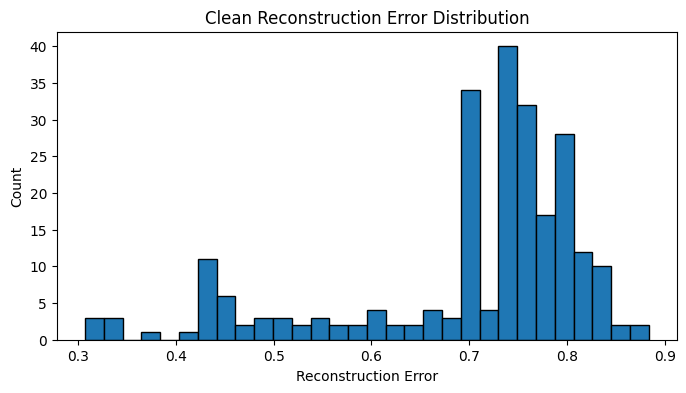

In [40]:
plt.figure(figsize=(8,4))

plt.hist(
    errors,
    bins=30,
    edgecolor="black"
)

plt.title("Clean Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")

plt.show()

In [41]:
threshold = (
    np.mean(errors)
    + 3 * np.std(errors)
)

print("Anomaly Threshold:", threshold)

Anomaly Threshold: 1.0785418


In [42]:
import json

with open(
    "../src/models/threshold.json",
    "w"
) as f:

    json.dump(
        {
            "threshold": float(threshold)
        },
        f,
        indent=4
    )

print("Threshold saved.")

Threshold saved.


In [43]:
np.sum(errors > threshold)

np.int64(0)

In [44]:
len(errors)

238

In [45]:
print("Threshold:", threshold)

print(
    "Clean FP:",
    np.sum(errors > threshold)
)

print(
    "Total Clean:",
    len(errors)
)

print(
    "FPR:",
    100 * np.sum(errors > threshold) / len(errors)
)

Threshold: 1.0785418
Clean FP: 0
Total Clean: 238
FPR: 0.0
